In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import colorsys
import pandas as pd
from pathlib import Path
from hypo_sleep import Session, NumpyDecoder
import spikeinterface.full as si
import spikeinterface.preprocessing as spp
from scipy import signal, stats
import xarray as xr
import statsmodels.api as sm
from functools import partial
from ghostipy.dsp import signal_envelope
import json
import pdb
import os

In [2]:
data_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
full_dict = {
    "none": {
        "dates": [
            "2025-02-18_09-19-26",
            "2025-02-20_08-58-57",
            "2025-03-20_09-01-41",
            "2025-02-24_09-00-29",
            # "2025-02-26_09-05-08",
        ],
        "configs": [
            "5d77",
            "790d",
            "8a55",
            "3e4b",
            # "d205",
        ],
        "animal": ["HYDO03", "HYDO03", "HYDO03", "HYDO04"],  # , "HYDO04"],
    },
    "sleep": {
        "dates": [
            "2025-02-19_08-59-23",
            "2025-03-03_08-55-10",
            "2025-02-25_09-06-23",
            "2025-03-07_08-52-44",
        ],
        "configs": [
            "d628",
            "c687",
            "073a",
            "9080",
        ],
        "animal": ["HYDO03", "HYDO03", "HYDO04", "HYDO04"],
    },
    "food": {
        "dates": [
            "2025-02-21_09-04-29",
            "2025-02-28_09-02-06",
            "2025-03-04_08-55-25",
        ],
        "configs": [
            "a964",
            "0674",
            "bc96",
        ],
        "animal": ["HYDO03", "HYDO03", "HYDO04"],
    },
}
depth_ordered_chs = np.array(
    [
        "24",
        "23",
        "25",
        "22",
        "8",
        "7",
        "9",
        "6",
        "15",
        "0",
        "14",
        "1",
        "26",
        "21",
        "27",
        "20",
        "10",
        "5",
        "28",
        "19",
        "11",
        "4",
        "29",
        "18",
        "12",
        "3",
        "30",
        "17",
        "13",
        "2",
        "31",
        "16",
    ]
)

In [11]:
work_dir = os.environ["WORK"]
triggers = ["so-peak", "spi-peak", "nrem-null"]
trig_data_dict = {
    cond: {date: {trigger: {} for trigger in triggers} for date in meta_dict["dates"]}
    for cond, meta_dict in full_dict.items()
}
print("loading spectra")
# for cond, meta_dict in full_dict.items():
cond = "none"
meta_dict = full_dict[cond]
for animal, date, config_id in zip(
    meta_dict["animal"], meta_dict["dates"], meta_dict["configs"]
):
    tmp_output_path = Path(
        work_dir,
        "hypo_sleep/processed_data/",
        animal,
        date,
        config_id,
        "spectra",
    )
    for trigger, tmp_dict in trig_data_dict[cond][date].items():
        for region in ["ctx", "hyp"]:
            print(animal, date, trigger, region)
            load_path = Path(
                tmp_output_path,
                f"spectra_39_{trigger}_meth-gsp_mtm_spectrogram_{region}_{config_id}.nc",
            )
            if load_path.exists():
                tmp_da = xr.load_dataarray(load_path, engine="h5netcdf")
                tmp_dict[region] = tmp_da
            else:
                tmp_dict[region] = None
                print(f"File not found: {load_path}")
                continue

loading spectra
HYDO03 2025-02-18_09-19-26 so-peak ctx
HYDO03 2025-02-18_09-19-26 so-peak hyp
HYDO03 2025-02-18_09-19-26 spi-peak ctx
HYDO03 2025-02-18_09-19-26 spi-peak hyp
HYDO03 2025-02-18_09-19-26 nrem-null ctx
HYDO03 2025-02-18_09-19-26 nrem-null hyp
HYDO03 2025-02-20_08-58-57 so-peak ctx
HYDO03 2025-02-20_08-58-57 so-peak hyp
HYDO03 2025-02-20_08-58-57 spi-peak ctx
HYDO03 2025-02-20_08-58-57 spi-peak hyp
HYDO03 2025-02-20_08-58-57 nrem-null ctx
HYDO03 2025-02-20_08-58-57 nrem-null hyp
HYDO03 2025-03-20_09-01-41 so-peak ctx
HYDO03 2025-03-20_09-01-41 so-peak hyp
HYDO03 2025-03-20_09-01-41 spi-peak ctx
HYDO03 2025-03-20_09-01-41 spi-peak hyp
HYDO03 2025-03-20_09-01-41 nrem-null ctx
HYDO03 2025-03-20_09-01-41 nrem-null hyp
HYDO04 2025-02-24_09-00-29 so-peak ctx
File not found: /gpfs01/born/animal/DanielG/hypo_sleep/processed_data/HYDO04/2025-02-24_09-00-29/3e4b/spectra/spectra_39_so-peak_meth-gsp_mtm_spectrogram_ctx_3e4b.nc
HYDO04 2025-02-24_09-00-29 so-peak hyp
File not found: /gpf

In [13]:
config_path = Path(work_dir, "hypo_sleep/processed_data/")
session_dict = {}
animal_dict = full_dict["none"]
for animal, date, config_id in zip(
    animal_dict["animal"], animal_dict["dates"], animal_dict["configs"]
):
    with open(Path(config_path, animal, date, config_id, "state_dict.json"), "r") as f:
        state_dict = json.load(f, cls=NumpyDecoder)
    session_dict[date] = state_dict

In [ ]:
tfr_epoch_dict = {
    cond: {
        reg: {
            trigger: {animal: None for animal in ["HYDO03", "HYDO04"]}
            for trigger in triggers
        }
        for reg in ["ctx", "hyp"]
    }
    for cond in ["none", "sleep", "food"]
}
frames = []
# for cond, date_psd in state_data_dict.items():
cond = "none"
date_tfr = trig_data_dict[cond]
for date, trig_tfr in date_tfr.items():
    state_times = session_dict[date]["NREM"]["times"].T
    for trig, reg_tfr in trig_tfr.items():
        for reg, data in reg_tfr.items():
            animal = [
                animal
                for animal, tmp_date in zip(
                    full_dict[cond]["animal"], full_dict[cond]["dates"]
                )
                if tmp_date == date
            ][0]

            if data is None:
                continue
            import pdb

            pdb.set_trace()
            data = data.set_index(trial="timestamps")
            data = data.sortby("trial")

            if reg == "ctx":
                data = data.sel(channel="39")  # LFP channel in cortex
            freq_res = data.freq[-1] - data.freq[-2]
            factor = int(0.5 / freq_res)
            try:
                data.sel(trial=slice(state_times[0, 0], state_times[0, 1]))
            except KeyError:
                pdb.set_trace()
            epochs = [
                data.sel(trial=slice(start, stop - 4))
                .mean(dim="trial", skipna=True)
                # .coarsen(freq=factor, boundary="trim", side="right")
                # .mean()
                for start, stop in state_times
            ]
            good_epochs = [
                epoch
                for epoch in epochs
                if not xr.ufuncs.isnan(epoch).sum() == epoch.size
            ]
            # data = data.coarsen(freq=factor, boundary="trim", side="right").mean()
            trig_data = xr.concat(good_epochs, dim="epoch")
            trig_data.assign_coords(freq=np.round(trig_data.freq, 1))
            tfr_epoch_dict[cond][reg][trig][animal] = trig_data

> /tmp/ipykernel_4072563/2534582419.py(32)<module>()
     30 
     31             pdb.set_trace()
---> 32             data = data.set_index(trial="start")
     33             data = data.sortby("trial")
     34 

<xarray.DataArray (channel: 2, trial: 3069, time: 79, freq: 63)> Size: 244MB
array([[[[7.15480556e+02, 1.06248148e+03, 7.99566656e+02, ...,
          9.18303336e-04, 3.46193885e-04, 3.93535897e-04],
         [2.64397557e+02, 4.67068228e+02, 4.71726945e+02, ...,
          5.43635151e-03, 3.09607164e-03, 4.20276824e-03],
         [1.49858517e+02, 3.13892697e+02, 2.75502125e+02, ...,
          1.54596145e-02, 1.13646407e-02, 1.24815776e-02],
         ...,
         [2.61249949e+01, 1.09040332e+02, 1.41063337e+02, ...,
          8.58641579e-04, 8.03092522e-04, 1.06500002e-03],
         [8.48862407e+01, 1.15714015e+02, 1.85322654e+02, ...,
          2.65210670e-04, 1.30496118e-04, 1.73816245e-04],
         [3.98511808e+01, 9.79205754e+01, 1.48553274e+02, ...,
          4.67636741e-0

In [7]:
frames = []
psd_state_dict = psd_epoch_dict[cond]
for region, reg_data in psd_state_dict.items():
    for trig, trig_data in reg_data.items():
        for animal, animal_data in trig_data.items():
            df = (
                animal_data.sel(freq=slice(0, 45))
                .to_dataframe(name="value")
                .reset_index()
            )
            df.freq = np.round(df.freq, 1)
            df["condition"] = cond
            df["region"] = region
            df["trig"] = trig
            df["animal"] = animal

            frames.append(df)
df_all = pd.concat(frames, ignore_index=True)

In [8]:
hyp_df = df_all.loc[df_all.region == "hyp", :].drop(
    columns=["region", "condition"], inplace=False
)
## To select only HYDO03 ##
# hyp_df = hyp_df.loc[hyp_df["animal"] == "HYDO03", :]
## ------ ##
mean_df = hyp_df.groupby(["trig", "epoch", "freq", "animal"]).agg({"value": np.nanmean})
mean_df = mean_df.reset_index()

In [9]:
idx = pd.IndexSlice
freqs = mean_df.freq.unique()
stat_res = {}
for tmp_freq in freqs:
    tmp_df = mean_df.loc[(mean_df.freq == tmp_freq), :]
    model1 = sm.formula.mixedlm(
        "value ~ C(trig, Treatment(reference='nrem-null'))",
        data=tmp_df,
        groups=tmp_df.animal,
    ).fit(reml=False, **{"maxiter": 5000})
    model2 = sm.formula.mixedlm(
        "value ~ 1",
        data=tmp_df,
        groups=tmp_df.animal,
    ).fit(reml=False, **{"maxiter": 5000})
    chi_sq_1_2 = 2 * (model1.llf - model2.llf)
    df_1_2 = model1.df_modelwc - model2.df_modelwc
    p_value_1_2 = stats.chi2.sf(chi_sq_1_2, df_1_2)
    if p_value_1_2 < 0.05:
        model = model1
    else:
        model = model2
    stat_res[f"{tmp_freq:.01f}"] = {
        "model": model,
        "p_value": p_value_1_2,
    }

In [10]:
drop_df = df_all.loc[(df_all.condition == "none"), :].drop(columns=["condition"])
reg_trig_df = drop_df.groupby(["freq", "trig", "region"]).agg(
    {"value": ["mean", "sem"]}
)

In [11]:
# plt.hist(drop_df.loc[(drop_df.region == "hyp") & (drop_df.trig == "spi-peak"), :].value)

<>:40: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3579969/2669208631.py:40: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel("Power $[\log(\\frac{\mu V^{2}}{Hz})]$")


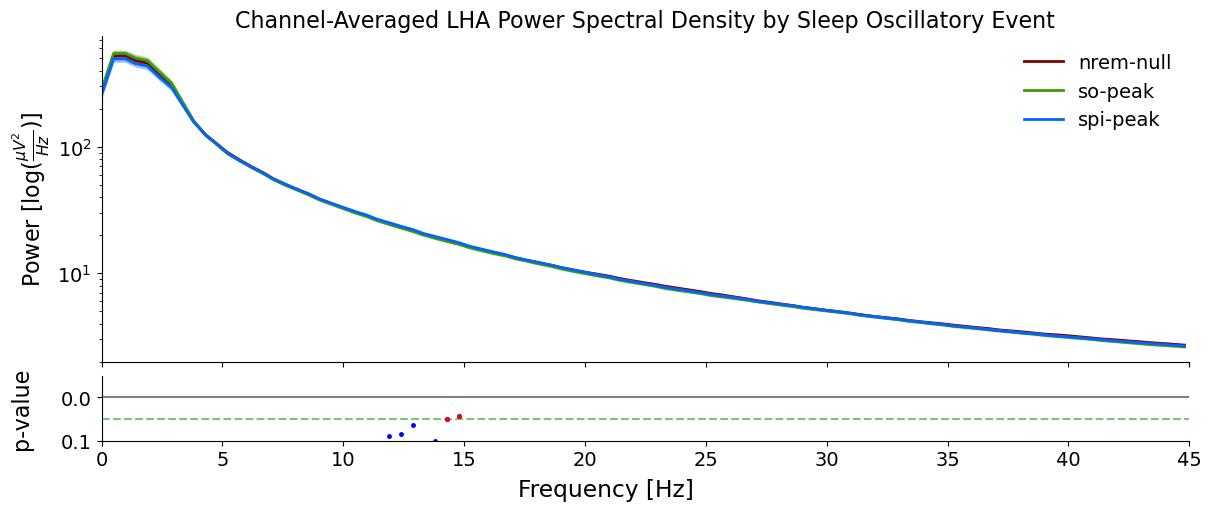

In [12]:
# trig_color_dict = {"nrem-all": "#1b9e77", "rem-all": "#7570b3", "wake-all": "#d95f02"}
trig_color_dict = {"spi-peak": "#0165fc", "so-peak": "#3f9b0b", "nrem-null": "#840000"}
region = "hyp"
fig, axs = plt.subplots(
    nrows=2,
    figsize=(12, 5),
    constrained_layout=True,
    height_ratios=[5, 1],
    sharex=True,
)
reg_df = reg_trig_df.loc[idx[:, :, region], :].reset_index()
ax = axs[0]
for trig, trig_df in reg_df.groupby("trig"):
    ax.plot(
        trig_df.freq,
        trig_df.value["mean"],
        label=trig,
        c=trig_color_dict[trig],
        lw=2,
    )
    ax.fill_between(
        x=trig_df.freq,
        y1=trig_df.value["mean"] - trig_df.value["sem"],
        y2=trig_df.value["mean"] + trig_df.value["sem"],
        color=trig_color_dict[trig],
        alpha=0.3,
    )
    ax.set_yscale("log", base=10)
    # ax.set_xscale("log")
# ax.set_yticks(
#     np.linspace(-2, 2, 5, endpoint=True),
#     labels=[f"$10^{{{int(val)}}}$" for val in np.linspace(-2, 2, 5, endpoint=True)],
# )
ax.set_xlim([0, 45])
# ax.set_ylim([-1, 2])
# ax.set_ylim([0, 100])
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Channel-Averaged LHA Power Spectral Density by Sleep Oscillatory Event")
ax.set_ylabel("Power $[\log(\\frac{\mu V^{2}}{Hz})]$")
ax = axs[1]
p_vals = {
    float(f): f_data["p_value"]
    for f, f_data in stat_res.items()
    if f_data["model"].converged
}
ax.axhline(0.0, ls="-", c="k", alpha=0.5)
ax.axhline(0.05, ls="--", c="g", alpha=0.5)
ax.plot(
    np.array(list(p_vals.keys()), dtype=float),
    np.array(list(p_vals.values())),
    ls="",
    marker=".",
    ms=5,
    c="b",
)
for f, p in p_vals.items():
    if p < 0.05:
        ax.plot(f, p, ls="", marker=".", ms=5, c="r")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim([0.1, -0.05])
# ax.set_yscale("log")
ax.set_ylabel("p-value", labelpad=20)
fig.supxlabel("Frequency [Hz]")  # , labelpad=15)
fig.savefig(
    Path(
        "/gpfs01/born/animal/DanielG/hypo_sleep/figures/",
        "hyp_psd_event_stats_all_gsp_2s.png",
    ),
    dpi=500,
    facecolor="white",
    transparent=False,
    bbox_inches="tight",
)

In [ ]:
trig_color_dict = {"spi-peak": "#0165fc", "so-peak": "#3f9b0b", "nrem-null": "#840000"}
fig, axs = plt.subplots(
    nrows=16,
    ncols=2,
    figsize=(17, 35),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)
region = "hyp"
reg_df = drop_df.loc[drop_df.region == "hyp", :]
for ch, ax in zip(depth_ordered_chs[::-1], axs.ravel()):
    ch_df = reg_df.loc[reg_df.channel == ch, :]
    for state in triggers:
        state_ch_df = ch_df.loc[ch_df.trig == state, :]
        state_ch_summ = state_ch_df.groupby(["freq"]).agg({"value": ["mean", "sem"]})
        ax.plot(
            state_ch_summ.index,
            state_ch_summ.value["mean"],
            label=state,
            c=trig_color_dict[state],
            lw=2,
        )
        ax.fill_between(
            x=state_ch_summ.index,
            y1=state_ch_summ.value["mean"] - state_ch_summ.value["sem"],
            y2=state_ch_summ.value["mean"] + state_ch_summ.value["sem"],
            color=trig_color_dict[state],
            alpha=0.4,
        )
    ax.set_title(f"ch {ch}")
    ax.set_yscale("log")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim([0, 45])
ax.legend(frameon=False)

# for trig, trig_xr in reg_df.items():
#     for ax, ch in zip(axs.ravel(), depth_ordered_chs):
#         ax.plot(
#             trig_xr.freq,
#             trig_xr.sel(channel=ch).mean(dim="trial"),
#             label=trig,
#             c=color_dict[trig],
#             lw=1,
#         )
#         tmp_sem = trig_xr.sel(channel=ch).std(dim="trial") / np.sqrt(
#             trig_xr.sizes["trial"]
#         )
#         ax.fill_between(
#             trig_xr.freq,
#             y1=trig_xr.sel(channel=ch).mean(dim="trial") - tmp_sem,
#             y2=trig_xr.sel(channel=ch).mean(dim="trial") + tmp_sem,
#             color=color_dict[trig],
#             alpha=0.4,
#         )
#         ax.set_title(f"ch {ch}")
#         ax.set_yscale("log")
#         ax.spines[["top", "right"]].set_visible(False)
#         # ax.set_xscale("log")
#         ax.set_xlim([0, 100])
#         ax.set_ylim([1e-1, 1e5])
# axs.ravel()[-1].legend()
# axs.ravel()[-2].set_xlabel("Frequency (Hz)")
# axs.ravel()[-1].set_xlabel("Frequency (Hz)")
# fig.suptitle(f"{cond} - across brain states; Depth-Sorted")
fig.supylabel("Power $[\log(\\frac{\mu V^{2}}{Hz})]$", x=-0.04)
# fig.savefig(
#     Path(f"/gpfs01/born/animal/DanielG/hypo_sleep/figures/ch-wise_PSD_xstates_hyp.png"),
#     facecolor="white",
#     transparent=False,
#     bbox_inches="tight",
#     dpi=500,
# )

In [ ]:
cond_reg_dict = {
    cond: {reg: {trig: [] for trig in triggers} for reg in ["ctx", "hyp"]}
    for cond in ["none", "sleep", "food"]
}
for cond, date_psd in state_data_dict.items():
    for date, trig_psd in date_psd.items():
        for trig, reg_psd in trig_psd.items():
            for reg, data in reg_psd.items():
                if data is None:
                    continue
                cond_reg_dict[cond][reg][trig].append(data)

In [ ]:
xr_dict = {}
for cond, cond_xr in cond_reg_dict.items():
    xr_dict[cond] = {}
    for reg, reg_xr in cond_xr.items():
        xr_dict[cond][reg] = {}
        for trig, trig_xr in reg_xr.items():
            tmp_xr = xr.concat(trig_xr, dim="trial")
            xr_dict[cond][reg][trig] = tmp_xr.assign_coords(
                trial=range(tmp_xr.sizes["trial"])
            )

### Cortex

In [ ]:
axs_dict = {
    trig: plt.subplots(nrows=1, figsize=(8, 5), constrained_layout=True)
    for trig in triggers
}
color_dict = {
    state: col
    for state, col in zip(["none", "sleep", "food"], ["#0057e7", "#d62d20", "#008744"])
}
for cond, cond_xr in xr_dict.items():
    reg_xr = cond_xr["ctx"]
    for trig, trig_xr in reg_xr.items():
        ax = axs_dict[trig][1]
        ax.plot(trig_xr.freq, trig_xr.sel(channel="39").mean(dim="trial"), label=cond)
        tmp_sem = trig_xr.sel(channel="39").std(dim="trial") / np.sqrt(
            trig_xr.sizes["trial"]
        )
        ax.fill_between(
            trig_xr.freq,
            y1=trig_xr.sel(channel="39").mean(dim="trial") - tmp_sem,
            y2=trig_xr.sel(channel="39").mean(dim="trial") + tmp_sem,
            color=color_dict[cond],
            alpha=0.4,
        )
        ax.set_title(f"{trig} - across exp conditions; ch 39")
        ax.set_yscale("log")
        ax.set_xlim([0, 100])
        ax.set_ylim([1e-1, 1e4])
        ax.spines[["top", "right"]].set_visible(False)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Power $[\log(\\frac{\mu V^{2}}{Hz})]$", x=-0.04)
for trig, ax in axs_dict.items():
    ax[1].legend()
    ax[0].savefig(
        Path(
            f"/gpfs01/born/animal/DanielG/hypo_sleep/figures/{trig}_PSD_xconds_ctx.png"
        ),
        facecolor="white",
        transparent=False,
        bbox_inches="tight",
        dpi=600,
    )

In [ ]:
color_dict = {
    trig: col for trig, col in zip(triggers, ["#0057e7", "#d62d20", "#008744"])
}

for cond, cond_xr in xr_dict.items():
    fig, ax = plt.subplots(
        figsize=(8, 5),
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )
    reg_xr = cond_xr["ctx"]
    for trig, trig_xr in reg_xr.items():
        ax.plot(trig_xr.freq, trig_xr.sel(channel="39").mean(dim="trial"), label=trig)
        tmp_sem = trig_xr.sel(channel="39").std(dim="trial") / np.sqrt(
            trig_xr.sizes["trial"]
        )
        ax.fill_between(
            trig_xr.freq,
            y1=trig_xr.sel(channel="39").mean(dim="trial") - tmp_sem,
            y2=trig_xr.sel(channel="39").mean(dim="trial") + tmp_sem,
            color=color_dict[trig],
            alpha=0.4,
        )
        ax.set_title(f"{cond} - across brain states; ch 39")
        ax.set_yscale("log")
        ax.set_xlim([0, 100])
        ax.set_ylim([1e-1, 1e4])
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Power $[\log(\\frac{\mu V^{2}}{Hz})]$", x=-0.04)
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend()
    fig.savefig(
        Path(
            f"/gpfs01/born/animal/DanielG/hypo_sleep/figures/{cond}_PSD_xtrigs_ctx.png"
        ),
        facecolor="white",
        transparent=False,
        bbox_inches="tight",
        dpi=600,
    )

In [ ]:
axs_dict = {
    trig: plt.subplots(
        nrows=16,
        ncols=2,
        figsize=(17, 35),
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )
    for trig in triggers
}
color_dict = {
    cond: col
    for cond, col in zip(["none", "sleep", "food"], ["#0057e7", "#d62d20", "#008744"])
}
for cond, cond_xr in xr_dict.items():
    reg_xr = cond_xr["hyp"]
    for trig, trig_xr in reg_xr.items():
        for ax, ch in zip(axs_dict[trig][1].ravel(), depth_ordered_chs):
            ax.plot(
                trig_xr.freq,
                trig_xr.sel(channel=ch).mean(dim="trial"),
                label=cond,
                c=color_dict[cond],
                lw=1,
            )
            tmp_sem = trig_xr.sel(channel=ch).std(dim="trial") / np.sqrt(
                trig_xr.sizes["trial"]
            )
            ax.fill_between(
                trig_xr.freq,
                y1=trig_xr.sel(channel=ch).mean(dim="trial") - tmp_sem,
                y2=trig_xr.sel(channel=ch).mean(dim="trial") + tmp_sem,
                color=color_dict[cond],
                alpha=0.4,
            )
            ax.set_title(f"ch {ch}")
            ax.set_yscale("log")
            ax.spines[["top", "right"]].set_visible(False)
            # ax.set_xscale("log")
            ax.set_ylim([1e-1, 1e4])
            ax.set_xlim([0, 100])
for axs in axs_dict.values():
    axs[1].ravel()[-1].legend()
    axs[1].ravel()[-2].set_xlabel("Frequency (Hz)")
    axs[1].ravel()[-1].set_xlabel("Frequency (Hz)")
    axs[0].supylabel("Power $[\log(\\frac{\mu V^{2}}{Hz})]$", x=-0.04)
for trig, fig in axs_dict.items():
    fig[0].suptitle(f"{trig} - across exp. conditions; Depth-Sorted")
    fig[0].savefig(
        Path(
            f"/gpfs01/born/animal/DanielG/hypo_sleep/figures/{trig}_PSD_xconds_hyp.png"
        ),
        facecolor="white",
        transparent=False,
        bbox_inches="tight",
        dpi=600,
    )

In [ ]:
color_dict = {
    trig: col for trig, col in zip(triggers, ["#0057e7", "#d62d20", "#008744"])
}
for cond, cond_xr in xr_dict.items():
    fig, axs = plt.subplots(
        nrows=16,
        ncols=2,
        figsize=(17, 35),
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )
    reg_xr = cond_xr["hyp"]
    for trig, trig_xr in reg_xr.items():
        for ax, ch in zip(axs.ravel(), depth_ordered_chs):
            ax.plot(
                trig_xr.freq,
                trig_xr.sel(channel=ch).mean(dim="trial"),
                label=trig,
                c=color_dict[trig],
                lw=1,
            )
            tmp_sem = trig_xr.sel(channel=ch).std(dim="trial") / np.sqrt(
                trig_xr.sizes["trial"]
            )
            ax.fill_between(
                trig_xr.freq,
                y1=trig_xr.sel(channel=ch).mean(dim="trial") - tmp_sem,
                y2=trig_xr.sel(channel=ch).mean(dim="trial") + tmp_sem,
                color=color_dict[trig],
                alpha=0.4,
            )
            ax.set_title(f"ch {ch}")
            ax.set_yscale("log")
            ax.spines[["top", "right"]].set_visible(False)
            # ax.set_xscale("log")
            ax.set_xlim([0, 100])
            ax.set_ylim([1e-1, 1e4])
    axs.ravel()[-1].legend()
    axs.ravel()[-2].set_xlabel("Frequency (Hz)")
    axs.ravel()[-1].set_xlabel("Frequency (Hz)")
    fig.supylabel("Power $[\log(\\frac{\mu V^{2}}{Hz})]$", x=-0.04)
    fig.suptitle(f"{cond} - across events; Depth-Sorted")
    fig.savefig(
        Path(
            f"/gpfs01/born/animal/DanielG/hypo_sleep/figures/{cond}_PSD_xtrigs_hyp.png"
        ),
        facecolor="white",
        transparent=False,
        bbox_inches="tight",
        dpi=600,
    )